# LAN: Low-Light Image Enhancement on the LOL Dataset

This notebook trains and evaluates **LAN**, a lightweight dual-branch
convolutional network for restoring normal illumination in low-light
photographs, using the [LOL dataset](https://daooshee.github.io/BMVC2018website/)
(485 paired training images, 15 paired evaluation images).

**Approach.** Inspired by Retinex theory, the network decomposes the problem
into two cooperating branches:

- **Reflectance branch** — a multi-scale convolutional encoder that extracts
  structural / texture features that should stay roughly constant regardless
  of illumination.
- **Illumination branch** — an encoder + iterative residual refinement module
  that progressively estimates a corrected illumination map.

The two branches are fused with a `1x1` convolution and decoded into the
final enhanced RGB image.

**What this notebook covers:**
1. Dataset loading, visualization, and light augmentation
2. Model architecture
3. A combined MSE + SSIM loss
4. Training with a held-out validation split, tracked PSNR/SSIM per epoch
5. Loss/metric curves
6. Qualitative comparison against a classical baseline (CLAHE)
7. Multi-image qualitative results on the test set
8. Final quantitative results summary


## 1. Setup

Install dependencies and unzip the dataset. This cell is written for Google
Colab — if you're running locally, `pip install` the same packages and skip
the `!unzip` line (point `DATA_ROOT` below at wherever you've already
extracted the LOL dataset).


In [4]:
# Colab / environment setup
!pip install -q scikit-image

# If your dataset is zipped in /content, unzip it (skip this if running
# locally with the dataset already extracted).
!unzip -q "/content/LOL_Dataset.zip" -d /content/


In [5]:
import os
import glob
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from torchvision.transforms import functional as TF

from PIL import Image

from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity as ssim_metric

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")


Using device: cuda


## 2. Dataset

Update `DATA_ROOT` to point at your extracted `lol_dataset` folder. Expected
layout:

```
lol_dataset/
    our485/
        low/    -> 485 low-light training images
        high/   -> 485 corresponding normal-light images
    eval15/
        low/    -> 15 low-light evaluation images
        high/   -> 15 corresponding normal-light images
```

The dataset class below optionally applies light augmentation (random
horizontal flip + random crop) — this matters a lot here since we only have
485 training pairs.


In [6]:
DATA_ROOT = "/content/lol_dataset"   # <-- update this path

TRAIN_LOW_DIR = os.path.join(DATA_ROOT, "our485", "low")
TRAIN_HIGH_DIR = os.path.join(DATA_ROOT, "our485", "high")
TEST_LOW_DIR = os.path.join(DATA_ROOT, "eval15", "low")
TEST_HIGH_DIR = os.path.join(DATA_ROOT, "eval15", "high")

IMAGE_SIZE = 256


In [7]:
class LowLightDataset(Dataset):
    """Paired (low-light, normal-light) LOL images, with optional
    augmentation for the training split (random crop + horizontal flip).
    Both images in a pair receive the *same* random transform."""

    def __init__(self, low_dir, high_dir, image_size=256, augment=False):
        self.low_paths = sorted(glob.glob(os.path.join(low_dir, "*")))
        self.high_paths = sorted(glob.glob(os.path.join(high_dir, "*")))

        assert len(self.low_paths) == len(self.high_paths), (
            f"Mismatched pair counts: {len(self.low_paths)} vs {len(self.high_paths)}"
        )

        self.image_size = image_size
        self.augment = augment
        self.resize = transforms.Resize((image_size, image_size))

    def __len__(self):
        return len(self.low_paths)

    def _paired_transform(self, low_img, high_img):
        low_img = self.resize(low_img)
        high_img = self.resize(high_img)

        if self.augment:
            # Random horizontal flip (applied identically to both images)
            if random.random() > 0.5:
                low_img = TF.hflip(low_img)
                high_img = TF.hflip(high_img)

            # Small random rotation for extra variety
            if random.random() > 0.5:
                angle = random.choice([0, 90, 180, 270])
                if angle != 0:
                    low_img = TF.rotate(low_img, angle)
                    high_img = TF.rotate(high_img, angle)

        low_tensor = TF.to_tensor(low_img)
        high_tensor = TF.to_tensor(high_img)
        return low_tensor, high_tensor

    def __getitem__(self, idx):
        low_img = Image.open(self.low_paths[idx]).convert("RGB")
        high_img = Image.open(self.high_paths[idx]).convert("RGB")
        return self._paired_transform(low_img, high_img)


In [8]:
full_train_dataset = LowLightDataset(TRAIN_LOW_DIR, TRAIN_HIGH_DIR, image_size=IMAGE_SIZE, augment=True)

# Hold out 10% of our485 as a validation split (in addition to eval15, which
# we reserve purely for final reporting)
val_size = max(1, int(0.1 * len(full_train_dataset)))
train_size = len(full_train_dataset) - val_size
train_dataset, val_dataset = random_split(
    full_train_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(SEED)
)
# Validation should not be augmented
val_dataset.dataset.augment = False

test_dataset = LowLightDataset(TEST_LOW_DIR, TEST_HIGH_DIR, image_size=IMAGE_SIZE, augment=False)

BATCH_SIZE = 4
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train pairs: {len(train_dataset)} | Val pairs: {len(val_dataset)} | Test pairs: {len(test_dataset)}")


Train pairs: 437 | Val pairs: 48 | Test pairs: 15


### 2.1 Visualize a few training pairs

Sanity-check the data before spending any GPU time on it.

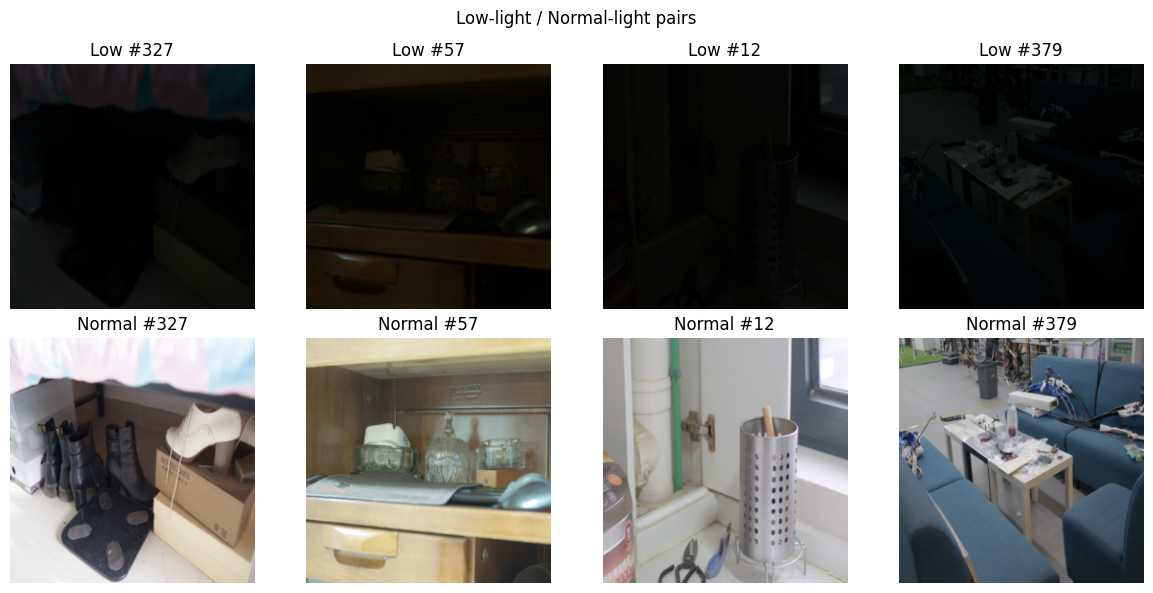

In [9]:
def show_pairs(dataset, n=4, title="Low-light / Normal-light pairs"):
    fig, axes = plt.subplots(2, n, figsize=(3 * n, 6))
    indices = random.sample(range(len(dataset)), n)

    for col, idx in enumerate(indices):
        low_img, high_img = dataset[idx]
        axes[0, col].imshow(low_img.permute(1, 2, 0).numpy())
        axes[0, col].set_title(f"Low #{idx}")
        axes[0, col].axis("off")

        axes[1, col].imshow(high_img.permute(1, 2, 0).numpy())
        axes[1, col].set_title(f"Normal #{idx}")
        axes[1, col].axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

show_pairs(full_train_dataset, n=4)


## 3. Model architecture

```
Low-light image (H, W, 3)
        |
        +--> ReflectanceEstimator -----> reflectance features (128-ch)
        |                                          |
        +--> IlluminationEnhancer -----> illumination map (3-ch, resized)
                                                     |
                                        concat + 1x1 fusion conv
                                                     |
                                             SynthesisModule
                                                     |
                                     Enhanced image (H, W, 3), sigmoid
```


In [10]:
class ResidualBlock(nn.Module):
    """Simple 2-conv residual block with identity skip connection."""

    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1),
        )

    def forward(self, x):
        return x + self.block(x)


class FeatureBlock(nn.Module):
    """Conv -> ReLU -> ResidualBlock -> Conv -> ReLU feature extractor."""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            ResidualBlock(out_channels),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class ReflectanceEstimator(nn.Module):
    """Encodes structural / reflectance information at three spatial
    resolutions via strided convolutions between FeatureBlocks."""

    def __init__(self, in_channels=3, base_channels=32):
        super().__init__()
        self.stage1 = FeatureBlock(in_channels, base_channels)
        self.down1 = nn.Conv2d(base_channels, base_channels * 2, 3, stride=2, padding=1)
        self.stage2 = FeatureBlock(base_channels * 2, base_channels * 2)
        self.down2 = nn.Conv2d(base_channels * 2, base_channels * 4, 3, stride=2, padding=1)
        self.stage3 = FeatureBlock(base_channels * 4, base_channels * 4)

    def forward(self, x):
        s1 = self.stage1(x)
        d1 = self.down1(s1)
        s2 = self.stage2(d1)
        d2 = self.down2(s2)
        return self.stage3(d2)


class IlluminationEnhancer(nn.Module):
    """Encoder + iterative residual refinement + decoder producing a
    3-channel illumination map."""

    def __init__(self, in_channels=3, latent_channels=64, iterations=8):
        super().__init__()
        self.iterations = iterations

        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, latent_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(latent_channels, latent_channels, 3, padding=1),
        )
        self.refine = nn.Sequential(
            nn.Conv2d(latent_channels, latent_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            ResidualBlock(latent_channels),
            nn.Conv2d(latent_channels, latent_channels, 3, padding=1),
        )
        self.decoder = nn.Sequential(
            nn.Conv2d(latent_channels, latent_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(latent_channels, 3, 3, padding=1),
        )

    def forward(self, x):
        z = self.encoder(x)
        for _ in range(self.iterations):
            z = z + self.refine(z)
        return self.decoder(z)


class SynthesisModule(nn.Module):
    """Fuses reflectance + illumination features into the final RGB output."""

    def __init__(self, in_channels=128):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            ResidualBlock(64),
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 3, 1),
        )

    def forward(self, x):
        return torch.sigmoid(self.block(x))


class LAN(nn.Module):
    """Full low-light enhancement network: reflectance + illumination
    branches, fused and synthesized into the final enhanced image."""

    def __init__(self):
        super().__init__()
        self.reflectance = ReflectanceEstimator()
        self.illumination = IlluminationEnhancer()
        self.fusion = nn.Conv2d(128 + 3, 128, 1)
        self.synthesis = SynthesisModule()

    def forward(self, x):
        r = self.reflectance(x)
        i = self.illumination(x)
        i = F.interpolate(i, size=r.shape[2:], mode="bilinear", align_corners=False)

        fused = torch.cat([r, i], dim=1)
        fused = self.fusion(fused)

        out = self.synthesis(fused)
        out = F.interpolate(out, size=x.shape[2:], mode="bilinear", align_corners=False)
        return out


model = LAN().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {n_params:,}")


Total parameters: 1,267,238


## 4. Loss function

Plain MSE tends to produce blurry, desaturated outputs because it optimizes
for pixel-wise averages. We combine it with a differentiable SSIM term,
which better captures perceptual structure (contrast, luminance, and
structural similarity):

$$\mathcal{L} = \mathcal{L}_{MSE} + \lambda \cdot (1 - \text{SSIM})$$


In [11]:
class SSIMLoss(nn.Module):
    """Differentiable SSIM loss (single-scale, computed with a Gaussian
    window) for use as a training objective alongside MSE."""

    def __init__(self, window_size=11, channels=3):
        super().__init__()
        self.window_size = window_size
        self.channels = channels
        self.register_buffer("window", self._create_window(window_size, channels))

    @staticmethod
    def _gaussian(window_size, sigma=1.5):
        coords = torch.arange(window_size).float() - window_size // 2
        g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
        return g / g.sum()

    def _create_window(self, window_size, channels):
        _1d = self._gaussian(window_size).unsqueeze(1)
        _2d = _1d @ _1d.t()
        window = _2d.expand(channels, 1, window_size, window_size).contiguous()
        return window

    def forward(self, img1, img2):
        window = self.window.to(img1.device).type_as(img1)
        pad = self.window_size // 2

        mu1 = F.conv2d(img1, window, padding=pad, groups=self.channels)
        mu2 = F.conv2d(img2, window, padding=pad, groups=self.channels)

        mu1_sq, mu2_sq, mu1_mu2 = mu1 ** 2, mu2 ** 2, mu1 * mu2

        sigma1_sq = F.conv2d(img1 * img1, window, padding=pad, groups=self.channels) - mu1_sq
        sigma2_sq = F.conv2d(img2 * img2, window, padding=pad, groups=self.channels) - mu2_sq
        sigma12 = F.conv2d(img1 * img2, window, padding=pad, groups=self.channels) - mu1_mu2

        c1, c2 = 0.01 ** 2, 0.03 ** 2
        ssim_map = ((2 * mu1_mu2 + c1) * (2 * sigma12 + c2)) / (
            (mu1_sq + mu2_sq + c1) * (sigma1_sq + sigma2_sq + c2)
        )
        return 1 - ssim_map.mean()


class CombinedLoss(nn.Module):
    def __init__(self, ssim_weight=0.2):
        super().__init__()
        self.mse = nn.MSELoss()
        self.ssim = SSIMLoss()
        self.ssim_weight = ssim_weight

    def forward(self, pred, target):
        mse_loss = self.mse(pred, target)
        ssim_loss = self.ssim(pred, target)
        total = mse_loss + self.ssim_weight * ssim_loss
        return total, mse_loss.item(), ssim_loss.item()


## 5. Training

We train with the combined MSE+SSIM loss, evaluate PSNR/SSIM on the held-out
validation split after every epoch, and checkpoint the best-performing model
(by validation PSNR) in addition to the final one.


In [12]:
def tensor_to_numpy(t):
    return t.detach().cpu().clamp(0, 1).permute(1, 2, 0).numpy()


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_psnr, total_ssim, n = 0.0, 0.0, 0

    for low_img, gt_img in loader:
        low_img, gt_img = low_img.to(device), gt_img.to(device)
        enhanced = model(low_img)

        for i in range(enhanced.size(0)):
            pred_np = tensor_to_numpy(enhanced[i])
            gt_np = tensor_to_numpy(gt_img[i])
            total_psnr += psnr_metric(gt_np, pred_np, data_range=1.0)
            total_ssim += ssim_metric(gt_np, pred_np, data_range=1.0, channel_axis=2)
            n += 1

    return total_psnr / max(n, 1), total_ssim / max(n, 1)


In [13]:
EPOCHS = 50
LEARNING_RATE = 1e-4
CHECKPOINT_DIR = "checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

model = LAN().to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = CombinedLoss(ssim_weight=0.2)

history = {"train_loss": [], "val_psnr": [], "val_ssim": []}
best_psnr = -1.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for low_img, gt_img in train_loader:
        low_img, gt_img = low_img.to(DEVICE), gt_img.to(DEVICE)

        optimizer.zero_grad()
        enhanced = model(low_img)
        loss, mse_val, ssim_val = criterion(enhanced, gt_img)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    scheduler.step()
    avg_loss = running_loss / len(train_loader)
    val_psnr, val_ssim = evaluate(model, val_loader, DEVICE)

    history["train_loss"].append(avg_loss)
    history["val_psnr"].append(val_psnr)
    history["val_ssim"].append(val_ssim)

    if val_psnr > best_psnr:
        best_psnr = val_psnr
        torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, "lan_best.pth"))

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] "
        f"Loss: {avg_loss:.4f} | Val PSNR: {val_psnr:.2f} dB | Val SSIM: {val_ssim:.4f}"
    )

torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, "lan_final.pth"))
print("Training finished. Best val PSNR:", round(best_psnr, 2), "dB")


Epoch [1/50] Loss: 0.1346 | Val PSNR: 16.20 dB | Val SSIM: 0.5377
Epoch [2/50] Loss: 0.1086 | Val PSNR: 16.25 dB | Val SSIM: 0.6173
Epoch [3/50] Loss: 0.0938 | Val PSNR: 17.18 dB | Val SSIM: 0.6757
Epoch [4/50] Loss: 0.0876 | Val PSNR: 17.17 dB | Val SSIM: 0.6852
Epoch [5/50] Loss: 0.0857 | Val PSNR: 17.18 dB | Val SSIM: 0.7012
Epoch [6/50] Loss: 0.0827 | Val PSNR: 16.66 dB | Val SSIM: 0.6972
Epoch [7/50] Loss: 0.0806 | Val PSNR: 17.45 dB | Val SSIM: 0.7053
Epoch [8/50] Loss: 0.0802 | Val PSNR: 17.12 dB | Val SSIM: 0.7085
Epoch [9/50] Loss: 0.0788 | Val PSNR: 17.54 dB | Val SSIM: 0.7168
Epoch [10/50] Loss: 0.0796 | Val PSNR: 16.83 dB | Val SSIM: 0.7024
Epoch [11/50] Loss: 0.0778 | Val PSNR: 17.64 dB | Val SSIM: 0.7189
Epoch [12/50] Loss: 0.0765 | Val PSNR: 17.15 dB | Val SSIM: 0.7100
Epoch [13/50] Loss: 0.0783 | Val PSNR: 17.49 dB | Val SSIM: 0.7156
Epoch [14/50] Loss: 0.0751 | Val PSNR: 17.65 dB | Val SSIM: 0.7163
Epoch [15/50] Loss: 0.0749 | Val PSNR: 17.88 dB | Val SSIM: 0.7240
Epoc

### 5.1 Training curves

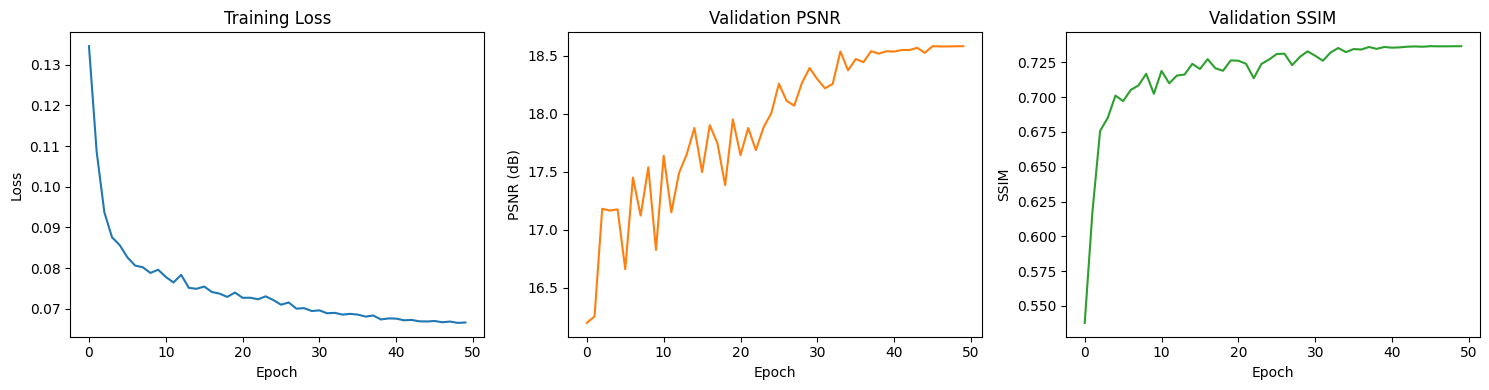

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history["train_loss"])
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

axes[1].plot(history["val_psnr"], color="tab:orange")
axes[1].set_title("Validation PSNR")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("PSNR (dB)")

axes[2].plot(history["val_ssim"], color="tab:green")
axes[2].set_title("Validation SSIM")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("SSIM")

plt.tight_layout()
plt.show()


## 6. Comparison against a classical baseline (CLAHE)

Before trusting the learned model, it's worth confirming it actually beats a
simple, well-known classical method: **CLAHE** (Contrast Limited Adaptive
Histogram Equalization). This uses OpenCV if available, otherwise
scikit-image's `equalize_adapthist`.


In [15]:
def clahe_enhance(low_img_tensor):
    """Apply CLAHE to a (3, H, W) tensor in [0, 1] and return a (3, H, W)
    tensor in [0, 1]."""
    img_np = (tensor_to_numpy(low_img_tensor) * 255).astype(np.uint8)

    try:
        import cv2
        lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        l = clahe.apply(l)
        lab = cv2.merge((l, a, b))
        result = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    except ImportError:
        from skimage.exposure import equalize_adapthist
        result = (equalize_adapthist(img_np / 255.0) * 255).astype(np.uint8)

    return torch.from_numpy(result / 255.0).permute(2, 0, 1).float()


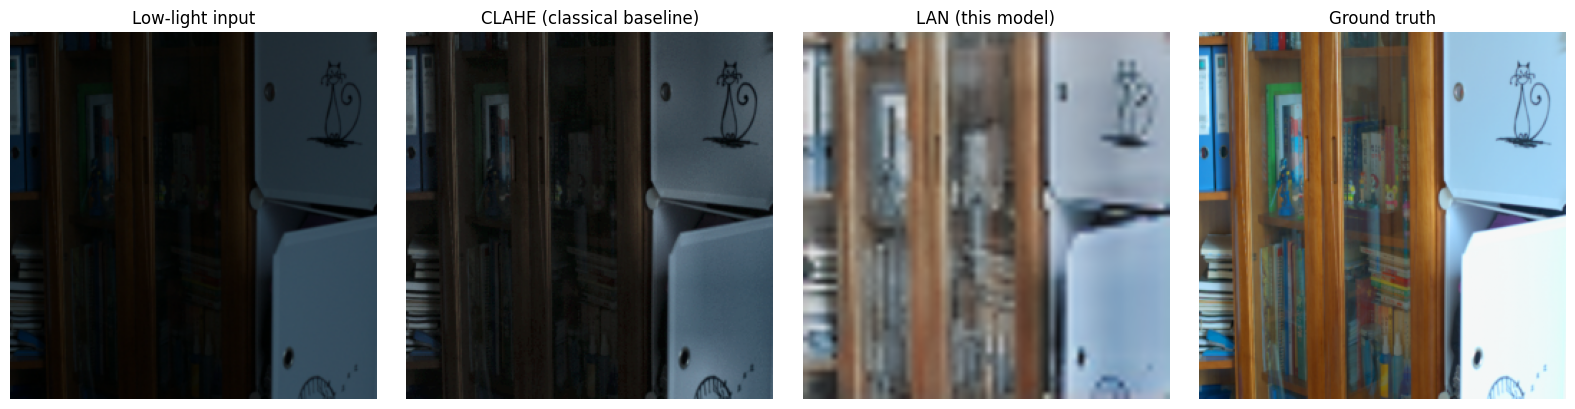

CLAHE   -> PSNR: 8.79 dB
LAN     -> PSNR: 15.50 dB


In [16]:
model.eval()
low_img, gt_img = test_dataset[0]

with torch.no_grad():
    model_out = model(low_img.unsqueeze(0).to(DEVICE)).squeeze(0).cpu()

clahe_out = clahe_enhance(low_img)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
titles = ["Low-light input", "CLAHE (classical baseline)", "LAN (this model)", "Ground truth"]
images = [low_img, clahe_out, model_out, gt_img]

for ax, img, title in zip(axes, images, titles):
    ax.imshow(tensor_to_numpy(img))
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

print(f"CLAHE   -> PSNR: {psnr_metric(tensor_to_numpy(gt_img), tensor_to_numpy(clahe_out), data_range=1.0):.2f} dB")
print(f"LAN     -> PSNR: {psnr_metric(tensor_to_numpy(gt_img), tensor_to_numpy(model_out), data_range=1.0):.2f} dB")


## 7. Qualitative results on multiple test images

A single hand-picked example can be misleading — here we run inference on
several `eval15` images at once.


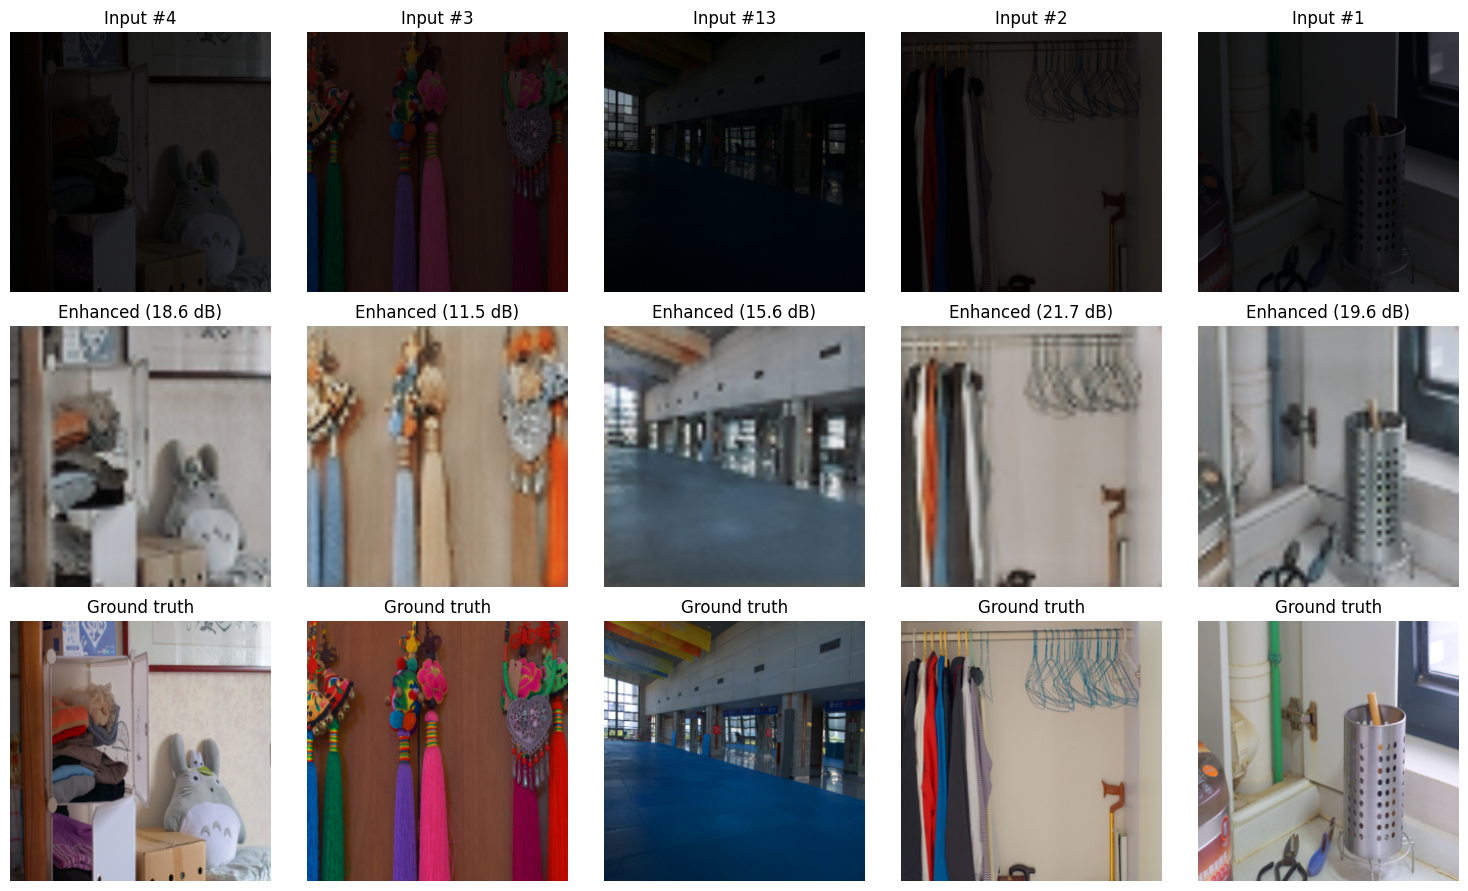

In [17]:
def show_results_grid(model, dataset, n=5, device=DEVICE):
    model.eval()
    indices = random.sample(range(len(dataset)), min(n, len(dataset)))

    fig, axes = plt.subplots(3, len(indices), figsize=(3 * len(indices), 9))

    for col, idx in enumerate(indices):
        low_img, gt_img = dataset[idx]
        with torch.no_grad():
            enhanced = model(low_img.unsqueeze(0).to(device)).squeeze(0).cpu()

        axes[0, col].imshow(tensor_to_numpy(low_img))
        axes[0, col].set_title(f"Input #{idx}")
        axes[0, col].axis("off")

        axes[1, col].imshow(tensor_to_numpy(enhanced))
        p = psnr_metric(tensor_to_numpy(gt_img), tensor_to_numpy(enhanced), data_range=1.0)
        axes[1, col].set_title(f"Enhanced ({p:.1f} dB)")
        axes[1, col].axis("off")

        axes[2, col].imshow(tensor_to_numpy(gt_img))
        axes[2, col].set_title("Ground truth")
        axes[2, col].axis("off")

    plt.tight_layout()
    plt.show()

show_results_grid(model, test_dataset, n=5)


## 8. Final results summary

Load the best checkpoint (by validation PSNR) and report final metrics on
the held-out `eval15` test set — the numbers to quote in a README / CV.


In [18]:
best_model = LAN().to(DEVICE)
best_model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, "lan_best.pth"), map_location=DEVICE))

test_psnr, test_ssim = evaluate(best_model, test_loader, DEVICE)
n_params = sum(p.numel() for p in best_model.parameters())

print("=" * 40)
print("FINAL RESULTS (eval15 test set, best checkpoint)")
print("=" * 40)
print(f"PSNR         : {test_psnr:.2f} dB")
print(f"SSIM         : {test_ssim:.4f}")
print(f"Parameters   : {n_params:,}")
print(f"Epochs run   : {EPOCHS}")
print("=" * 40)


FINAL RESULTS (eval15 test set, best checkpoint)
PSNR         : 17.64 dB
SSIM         : 0.7068
Parameters   : 1,267,238
Epochs run   : 50


## Next steps

- Try a perceptual (VGG-based) loss term in addition to MSE + SSIM
- Compare against learned baselines (Zero-DCE, RetinexNet, EnlightenGAN)
- Export the best checkpoint to TorchScript/ONNX for deployment
- Try higher-resolution training with patch-based cropping
